# SMS Spam Detection pomocu ANN modela

Cilj projekta je klasifikovati SMS poruke kao:

- spam
- ham

Koristimo UCI SMS Spam Collection dataset.

Pipeline projekta je sljedeci:

SMS tekst -> Tokenizer -> sekvence brojeva -> padding -> ANN model -> spam/ham

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout

In [63]:
!wget -q https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip
!unzip -q -o sms+spam+collection.zip

In [64]:
!ls

readme	     SMSSpamCollection	      sms+spam+collection.zip.1
sample_data  sms+spam+collection.zip  sms+spam+collection.zip.2


## Ucitavanje dataseta

Dataset se nalazi u fajlu `SMSSpamCollection`.

Svaki red ima dva dijela:

- labelu: `ham` ili `spam`
- tekst SMS poruke

Posto fajl nema nazive kolona, rucno dodajemo kolone `label` i `message`.

In [65]:
df = pd.read_csv(
    "SMSSpamCollection",
    sep="\t",
    names=["label", "message"]
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [66]:
df.shape

(5572, 2)

In [67]:
df["label"].value_counts()

,count
label,
ham,4825
spam,747


## Brzinska analiza dataset-a

Dataset je nebalansiran, jer ima vise normalnih ham poruka nego spam poruka. Zato accuracy nije jedina dovoljna metrika, nego cemo kasnije da gledamo i `precision`, `recall` i `F1-score`, te cemo analizirati te rezultate.

In [68]:
df.isnull().sum()

,0
label,0
message,0


Nemamo nedostajucih vrijednosti unutar dataset-a.

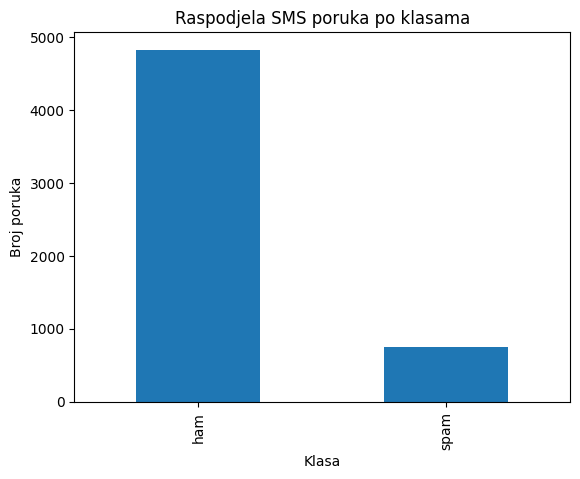

In [69]:
df["label"].value_counts().plot(kind="bar")

plt.title("Raspodjela SMS poruka po klasama")
plt.xlabel("Klasa")
plt.ylabel("Broj poruka")
plt.show()

## Pretvaranje labela u brojeve

Model ne može direktno raditi sa tekstualnim labelama `ham` i `spam`.

Zato ih pretvaramo u brojeve:

- `ham` -> 0
- `spam` -> 1

Posto zelimo predvidjeti da li je poruka spam, spam označavamo kao pozitivnu klasu `1`.

In [70]:
df["label_num"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


Sada odjavamo ulaz i izlaz:

`X` = tekstovi SMS poruka

`y` = klase 0/1

In [71]:
X = df["message"].values
y = df["label_num"].values

In [72]:
print("Primjer poruke:")
print(X[0])

print("\nLabela:")
print(y[0])

Primjer poruke:
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Labela:
0


## Podjela na trening i test skup

Podatke dijelimo na:

- trening skup: koristi se za ucenje modela
- test skup: koristi se za konacnu provjeru modela

Koristimo 80% podataka za trening i 20% za testiranje.

Parametar `stratify=y` cuva priblizno isti omjer `ham` i `spam` poruka u trening i test skupu. Bez stratify recimo, moze se desiti da test skup dobije premalo spam poruka, pa evaluacija ne bude realna, pa model ima visok accuracy samo zato sto dobro pogadja ham.

Takodjer, moguce je da model ne nauci dovoljno dobro spam da prepoznaje, jer u treningu nije vidio dovoljno spam primjera.

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [74]:
print("Broj trening poruka:", len(X_train))
print("Broj test poruka:", len(X_test))

Broj trening poruka: 4457
Broj test poruka: 1115


In [75]:
print("Omjer klasa u cijelom datasetu:")
print(pd.Series(y).value_counts(normalize=True))

print("\nOmjer klasa u trening skupu:")
print(pd.Series(y_train).value_counts(normalize=True))

print("\nOmjer klasa u test skupu:")
print(pd.Series(y_test).value_counts(normalize=True))

Omjer klasa u cijelom datasetu:
0    0.865937
1    0.134063
Name: proportion, dtype: float64

Omjer klasa u trening skupu:
0    0.865829
1    0.134171
Name: proportion, dtype: float64

Omjer klasa u test skupu:
0    0.866368
1    0.133632
Name: proportion, dtype: float64


Dakle, koristenjem stratify podijelu dobija se trening i test skup koji imaju priblizno isti omjer `spam` i `ham` poruka kao i originalni dataset.

## Tokenizacija teksta

Neuronska mreza ne moze direktno raditi sa tekstom.

Zato koristimo `Tokenizer`, koji svakoj rijeci dodjeljuje jedan broj.

Na primjer:

- "free" -> 15
- "call" -> 31
- "now" -> 57

Nakon tokenizacije, svaka SMS poruka postaje sekvenca brojeva.

Tokenizer ucimo samo na trening podacima, da ne bi model unaprijed vidio informacije iz test skupa.

In [76]:
VOCAB_SIZE = 10000
OOV_TOKEN = "<OOV>"

VOCAB_SIZE = maksimalan broj rijeci koje tokenizer cuva

OOV_TOKEN = oznaka za rijeci koje nisu vidjene u trening skupu

In [77]:
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token=OOV_TOKEN
)

In [78]:
tokenizer.fit_on_texts(X_train)

In [79]:
word_index = tokenizer.word_index

print("Broj rijeci u riječniku:", len(word_index))
print("Prvih 20 rijeci:")
print(list(word_index.items())[:20])

Broj rijeci u riječniku: 7934
Prvih 20 rijeci:
[('<OOV>', 1), ('i', 2), ('to', 3), ('you', 4), ('a', 5), ('the', 6), ('u', 7), ('and', 8), ('in', 9), ('is', 10), ('my', 11), ('me', 12), ('for', 13), ('your', 14), ('it', 15), ('call', 16), ('of', 17), ('have', 18), ('on', 19), ('2', 20)]


## Pretvaranje teksta u sekvence brojeva

Nakon sto je Tokenizer napravio rjecnik, svaku SMS poruku pretvaramo u listu brojeva pomocu `texts_to_sequences`.

Na primjer:

"call me now"

moze postati:

[31, 18, 57]

In [80]:
train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences = tokenizer.texts_to_sequences(X_test)

In [81]:
print("Originalna poruka:")
print(X_train[0])

print("\nSekvenca brojeva:")
print(train_sequences[0])

Originalna poruka:
He will, you guys close?

Sekvenca brojeva:
[72, 33, 4, 339, 670]


## Padding

Sljedeci problem koji treba da se rjesi je taj da su neke SMS poruke kratke dok su neke SMS poruke duge. Neuronska mreza ocekuje da je svaki ulaz iste duzine i iz tog razloga cemo da koristimo padding.

Razlog za padding je zato sto neuronska mreza obradjuje podatke u matricama/tesnorima. Da bi se vise poruka moglo obraditi zajedno u batch-u, svaka poruka mora imati isti broj tokena.

Ako je poruka kraca od zadane duzine, dodaju se nule. Ako je poruka duza od zadane duzine, skracuje se.

In [82]:
MAX_LENGTH = 50
PADDING_TYPE = "post"
TRUNC_TYPE = "post"

MAX_LENGTH = svaka poruka ce imati 50 brojeva

PADDING_TYPE = "post" znaci da se nule dodaju na kraj

TRUNC_TYPE = "post" znaci da se preduge poruke skracuju sa kraja

In [83]:
X_train_padded = pad_sequences(
    train_sequences,
    maxlen=MAX_LENGTH,
    padding=PADDING_TYPE,
    truncating=TRUNC_TYPE
)

X_test_padded = pad_sequences(
    test_sequences,
    maxlen=MAX_LENGTH,
    padding=PADDING_TYPE,
    truncating=TRUNC_TYPE
)

In [84]:
print("Oblik trening podataka:", X_train_padded.shape)
print("Oblik test podataka:", X_test_padded.shape)

Oblik trening podataka: (4457, 50)
Oblik test podataka: (1115, 50)


Dakle imamo sada 4459 trening poruka , 1115 test poruka i svaka poruka ima 50 brojeva.

In [85]:
print("Originalna sekvenca:")
print(train_sequences[0])

print("\nSekvenca nakon paddinga:")
print(X_train_padded[0])

Originalna sekvenca:
[72, 33, 4, 339, 670]

Sekvenca nakon paddinga:
[ 72  33   4 339 670   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]


## Kreiranje ANN modela

Nakon tokenizacije i paddinga, tekstualne poruke su pretvorene u numericke sekvence.

Sada pravimo ANN model koji se sastoji od:

1. `Embedding` sloja
2. `GlobalAveragePooling1D` sloja
3. `Dense` sloja
4. `Dropout` sloja
5. izlaznog `Dense` sloja sa sigmoid aktivacijom

Posto imamo binarnu klasifikaciju, izlaz je jedna vrijednost između 0 i 1.

Vrijednost blizu 0 znaci `ham`, a vrijednost blizu 1 znaci `spam`.

In [86]:
EMBEDDING_DIM = 16

Ovo znaci da ce svaka rijec biti predstavljena vektorom od 16 brojeva. Na primjer rijec "free" nece biti samo jedan broj nego vektor [0.12, -0.44, 0.31, ..., 0.88].

In [87]:
model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    GlobalAveragePooling1D(),

    Dense(24, activation="relu"),

    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

## Kompajliranje modela

Prije treniranja moramo definisati:

- loss funkciju
- optimizer
- metrike

Koristimo `binary_crossentropy` jer imamo binarnu klasifikaciju.

Koristimo `adam` optimizer jer je standardan i efikasan za neuronske mreze.

Kao osnovnu metriku pratimo `accuracy`.

In [88]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [89]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Treniranje modela

Model treniramo na trening podacima.

Koristimo dio trening podataka za validaciju.

Validacija sluzi da vidimo kako se model ponasa na podacima koje ne koristi direktno za ucenje. Mozemo bez problema da stimamo validacijski skup tako da napravimo da se model ponasa bolje, bez da pretvorimo test skup u drugi trening skup.

In [90]:
EPOCHS = 15
BATCH_SIZE = 32

In [91]:
history = model.fit(
    X_train_padded,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=1
)

Epoch 1/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8698 - loss: 0.3758 - val_accuracy: 0.8430 - val_loss: 0.3614
Epoch 2/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8715 - loss: 0.3205 - val_accuracy: 0.8430 - val_loss: 0.3316
Epoch 3/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8724 - loss: 0.2740 - val_accuracy: 0.8453 - val_loss: 0.2698
Epoch 4/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9032 - loss: 0.2011 - val_accuracy: 0.9148 - val_loss: 0.1956
Epoch 5/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9602 - loss: 0.1423 - val_accuracy: 0.9507 - val_loss: 0.1498
Epoch 6/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9728 - loss: 0.1102 - val_accuracy: 0.9596 - val_loss: 0.1234
Epoch 7/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9798 - loss: 0.0911 - val_accuracy: 0.9675 - val_loss: 0.1040
Epoch 8/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9820 - loss: 0.0732 - val_accuracy: 0.

## Grafovi treniranja

Nakon treniranja prikazujemo accuracy i loss kroz epohe.

Ovi grafovi nam pomazu da vidimo da li model stvarno uci i da li dolazi do overfittinga.

Ako trening accuracy raste, a validation accuracy stagnira ili pada, to moze znaciti da model previse pamti trening podatke.

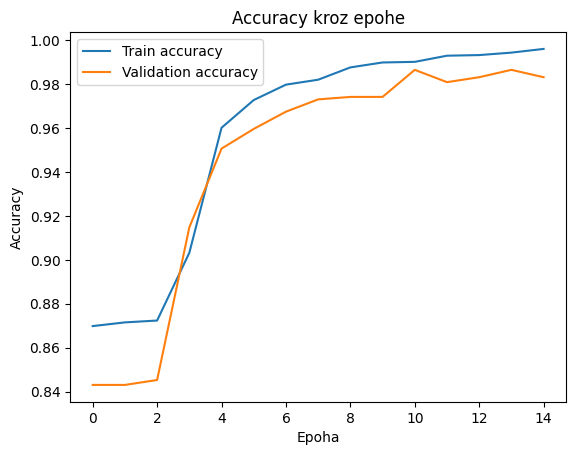

In [92]:
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")

plt.title("Accuracy kroz epohe")
plt.xlabel("Epoha")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

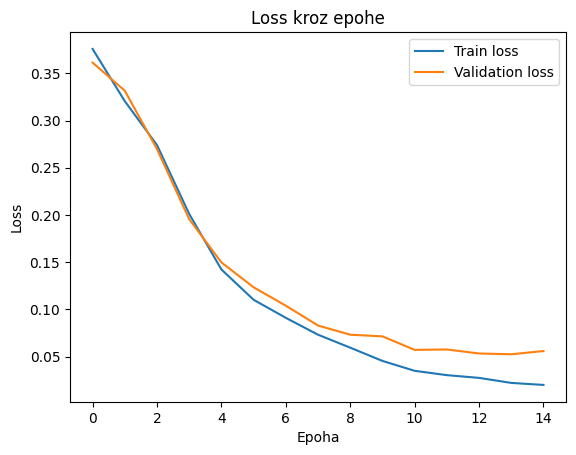

In [93]:
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")

plt.title("Loss kroz epohe")
plt.xlabel("Epoha")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Evaluacija na test skupu

Test skup nije koristen tokom treniranja modela.

Zato ga koristimo za konacnu provjeru performansi modela.

Na test skupu racunamo loss i accuracy.

In [94]:
test_loss, test_accuracy = model.evaluate(
    X_test_padded,
    y_test,
    verbose=0
)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Test loss: 0.05114542692899704
Test accuracy: 0.9856502413749695


## Predikcije na test skupu

Model kao izlaz daje vjerovatnocu da je poruka spam.

Posto koristimo sigmoid aktivaciju, izlaz je broj između 0 i 1.

Koristimo prag 0.5:

- ako je vrijednost >= 0.5, poruka je `spam`
- ako je vrijednost < 0.5, poruka je `ham`

In [95]:
y_prob = model.predict(X_test_padded)

y_pred = (y_prob >= 0.5).astype(int).flatten()

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [96]:
for i in range(10):
    print("Poruka:", X_test[i])
    print("Stvarna klasa:", "spam" if y_test[i] == 1 else "ham")
    print("Predikcija:", "spam" if y_pred[i] == 1 else "ham")
    print("Vjerovatnoca spam klase:", round(float(y_prob[i][0]), 4))
    print("-" * 80)

Poruka: No need to buy lunch for me.. I eat maggi mee..
Stvarna klasa: ham
Predikcija: ham
Vjerovatnoca spam klase: 0.0007
--------------------------------------------------------------------------------
Poruka: Ok im not sure what time i finish tomorrow but i wanna spend the evening with you cos that would be vewy vewy lubly! Love me xxx
Stvarna klasa: ham
Predikcija: ham
Vjerovatnoca spam klase: 0.0
--------------------------------------------------------------------------------
Poruka: Waiting in e car 4 my mum lor. U leh? Reach home already?
Stvarna klasa: ham
Predikcija: ham
Vjerovatnoca spam klase: 0.0002
--------------------------------------------------------------------------------
Poruka: You have won ?1,000 cash or a ?2,000 prize! To claim, call09050000327
Stvarna klasa: spam
Predikcija: spam
Vjerovatnoca spam klase: 0.9867
--------------------------------------------------------------------------------
Poruka: If you r @ home then come down within 5 min
Stvarna klasa: ham
P

Accuracy nije dovoljna metrika zato sto dataset nije balansiran. Ako ima mnogo vise ham poruka, model moze imati visoku accuracy cak i ako slabije prepoznaje spam, zato gledamo i `precision`, `recall` i `F1-score`.

In [97]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["ham", "spam"]
))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.99      0.90      0.94       149

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.99      0.99      0.99      1115



Kod spam detekcije, zelimo da model ima dobar recall za spam klasu, jer zelimo da sto manje spam poruka prodje kao normalna ham poruka.

## Confusion matrix

Confusion matrix prikazuje tacne i pogresne klasifikacije modela.

Za nas problem imamo dvije klase:

- `ham`
- `spam`

Posebno su bitne greske gdje model stvarnu `spam` poruku klasifikuje kao `ham`.

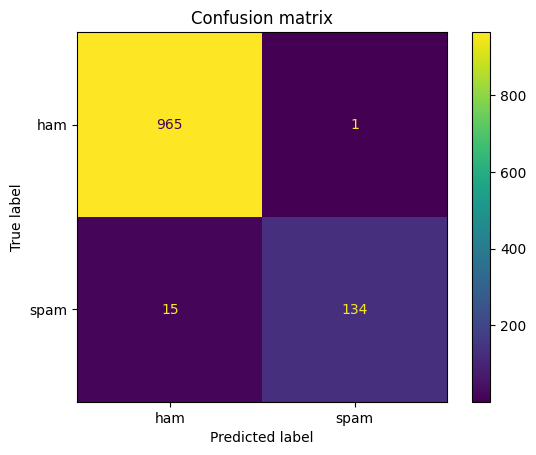

In [98]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["ham", "spam"]
)

disp.plot()
plt.title("Confusion matrix")
plt.show()

## Funkcija za klasifikaciju nove SMS poruke

Nakon treniranja i evaluacije modela, pravimo funkciju koja prima tekst nove SMS poruke i klasifikuje je kao `spam` ili `ham`.

Nova poruka mora proci kroz isti preprocessing kao i trening podaci:

1. tokenizacija
2. padding
3. predikcija modela

Model vraca vjerovatnocu da je poruka `spam`.

Ako je vjerovatnoca veca ili jednaka 0.5, poruku klasifikujemo kao `spam`.

Ako je vjerovatnoca manja od 0.5, poruku klasifikujemo kao `ham`.

In [99]:
def klasifikuj_sms(tekst):
    sekvenca = tokenizer.texts_to_sequences([tekst])

    padded = pad_sequences(
        sekvenca,
        maxlen=MAX_LENGTH,
        padding=PADDING_TYPE,
        truncating=TRUNC_TYPE
    )

    vjerovatnoca = model.predict(padded, verbose=0)[0][0]

    if vjerovatnoca >= 0.5:
        klasa = "spam"
    else:
        klasa = "ham"

    print("Poruka:", tekst)
    print("Vjerovatnoca spam klase:", round(float(vjerovatnoca), 4))
    print("Predikcija:", klasa)

    return klasa

## Testiranje modela na novim porukama

Sada testiramo model na nekoliko rucno napisanih SMS poruka.

Prva i treca poruka imaju tipicne spam rijeci kao sto su `won`, `free`, `ticket`, `urgent`, `prize` i `call`.

Druga poruka je obicna normalna poruka.

In [100]:
klasifikuj_sms("Congratulations! You won a free ticket. Call now.")

Poruka: Congratulations! You won a free ticket. Call now.
Vjerovatnoca spam klase: 0.6728
Predikcija: spam


'spam'

In [101]:
klasifikuj_sms("Hey, are we still meeting today?")

Poruka: Hey, are we still meeting today?
Vjerovatnoca spam klase: 0.0004
Predikcija: ham


'ham'

In [102]:
klasifikuj_sms("URGENT! You have won a prize. Text WIN to 80085 now.")

Poruka: URGENT! You have won a prize. Text WIN to 80085 now.
Vjerovatnoca spam klase: 0.9563
Predikcija: spam


'spam'

In [103]:
klasifikuj_sms("Can you call me when you get home?")

Poruka: Can you call me when you get home?
Vjerovatnoca spam klase: 0.0013
Predikcija: ham


'ham'

In [104]:
moja_poruka = input("Unesi SMS poruku: ")

klasifikuj_sms(moja_poruka)

Unesi SMS poruku: Congrats on your free prize! Call now to claim!
Poruka: Congrats on your free prize! Call now to claim!
Vjerovatnoca spam klase: 0.9684
Predikcija: spam


'spam'

## Zakljucak

U ovom projektu implementiran je ANN model za klasifikaciju SMS poruka kao `spam` ili `ham`.

Koristen je `UCI SMS Spam Collection` dataset.

Tekstualne SMS poruke prvo su pretvorene u numericki oblik pomocu `Tokenizer` klase. Nakon toga su sekvence izjednacene pomocu `pad_sequences`, jer neuronska mreza ocekuje ulaze iste duzine.

Model koristi sljedecu arhitekturu:

- `Embedding` sloj
- `GlobalAveragePooling1D` sloj
- `Dense` sloj
- `Dropout` sloj
- izlazni `Dense` sloj sa `sigmoid` aktivacijom

Posto je zadatak binarna klasifikacija, koristena je `binary_crossentropy` loss funkcija.

Model je evaluiran pomocu:

- accuracy
- precision
- recall
- F1-score
- confusion matrix

Na kraju je napravljena funkcija `klasifikuj_sms`, koja omogucava unos nove SMS poruke i vraca predikciju `spam` ili `ham`.